In [ ]:
#判別システム全体
#前処理フェーズ，判別フェーズ

#前処理フェーズ：YOLO
#入力：画像フォルダ
#出力：前処理後の画像

#判別フェーズ
#入力：画像フォルダ
#出力：判別結果

In [3]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [2]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from glob import glob

# --- 入力と出力の設定 ---
# (変更なし)
input_folders = ["/home/data/0620_dicomo_dataset/A", "/home/data/0620_dicomo_dataset/B", "/home/data/0620_dicomo_dataset/C"]
base_output_path = "/home/data/0620_dicomo_dataset/"
crop_output_base = os.path.join(base_output_path, "crop")
mask_output_base = os.path.join(base_output_path, "mask")
combined_output_base = os.path.join(base_output_path, "combined")
os.makedirs(crop_output_base, exist_ok=True)
os.makedirs(mask_output_base, exist_ok=True)
os.makedirs(combined_output_base, exist_ok=True)

# --- モデルの読み込み ---
# (モデルパスをユーザーのものに修正)
try:
    detection_model = YOLO('/home/YOLO/0620_bbox/datasets/train2/weights/best.pt')
    segmentation_model = YOLO("/home/YOLO/-327_seg/datasets/train2/weights/best.pt")
    print("YOLO models loaded successfully.")
except Exception as e:
    print(f"Error loading YOLO models: {e}")
    exit()

# --- 画像処理の実行 ---
for folder_path in input_folders:
    folder_name = os.path.basename(folder_path)
    crop_output_folder = os.path.join(crop_output_base, folder_name)
    mask_output_folder = os.path.join(mask_output_base, folder_name)
    combined_output_folder = os.path.join(combined_output_base, folder_name)
    os.makedirs(crop_output_folder, exist_ok=True)
    os.makedirs(mask_output_folder, exist_ok=True)
    os.makedirs(combined_output_folder, exist_ok=True)

    print(f"Processing folder: {folder_path}")
    
    image_paths = []
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPEG', '*.tif', '*.tiff'):
        image_paths.extend(glob(os.path.join(folder_path, ext)))

    for img_path in image_paths:
        try:
            original_image = cv2.imread(img_path)
            if original_image is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue

            detection_results = detection_model.predict(original_image, verbose=False)
          
            # 検出されたオブジェクトがある場合のみ処理を実行
            if detection_results and len(detection_results[0].boxes) > 0:
                
                # 1. 最も信頼度の高いボックスを選択
                boxes = detection_results[0].boxes
                # .conf (信頼度) のリストから最大値のインデックスを取得
                best_box_index = boxes.conf.argmax()
                # 最も信頼度の高いボックスオブジェクトを取得
                best_box = boxes[best_box_index]

                # 2. 選択したボックスに対してのみ処理を実行 (ループを削除)
                # バウンディングボックスの座標を取得 (x1, y1, x2, y2)
                xyxy = best_box.xyxy[0].cpu().numpy().astype(int)
                x1, y1, x2, y2 = xyxy

                # --- 拡大画像の作成 (クロップ) ---
                cropped_image = original_image[y1:y2, x1:x2]
                
                if cropped_image.size == 0:
                    print(f"Warning: Cropped image from {img_path} is empty. Skipping.")
                    continue

                # 3. 出力ファイル名をシンプルに変更 (1画像1出力のためインデックスを削除)
                base_filename = os.path.splitext(os.path.basename(img_path))[0]
                # "_box{i}" という接尾辞を削除
                output_filename_prefix = f"{base_filename}" 

                # 拡大画像を保存
                crop_save_path = os.path.join(crop_output_folder, f"{output_filename_prefix}_crop.png")
                cv2.imwrite(crop_save_path, cropped_image)

                # セグメンテーションを実行
                segmentation_results = segmentation_model.predict(cropped_image, verbose=False)

                if segmentation_results[0].masks is not None:
                    # マスク画像の作成
                    mask_image = np.zeros(cropped_image.shape[:2], dtype=np.uint8)
                    masks = segmentation_results[0].masks.xy
                    for seg in masks:
                        pts = np.array(seg, dtype=np.int32)
                        cv2.fillPoly(mask_image, [pts], (255, 255, 255))
                    
                    # マスク画像を保存
                    mask_save_path = os.path.join(mask_output_folder, f"{output_filename_prefix}_mask.png")
                    cv2.imwrite(mask_save_path, mask_image)

                    # 拡大画像とマスク画像の合成
                    mask_3ch = cv2.cvtColor(mask_image, cv2.COLOR_GRAY2BGR)
                    combined_image = cv2.bitwise_and(cropped_image, mask_3ch)

                    # 合成画像を保存
                    combined_save_path = os.path.join(combined_output_folder, f"{output_filename_prefix}_combined.png")
                    cv2.imwrite(combined_save_path, combined_image)
                else:
                    print(f"Warning: No segments found in cropped image from {img_path}.")
            
            else:
                # オブジェクトが一つも検出されなかった場合のメッセージ
                print(f"Info: No objects detected in {img_path}. Skipping.")

        except Exception as e:
            print(f"An error occurred while processing {img_path}: {e}")

print("--- Processing complete. ---")

YOLO models loaded successfully.
Processing folder: /home/data/0620_dicomo_dataset/A
Processing folder: /home/data/0620_dicomo_dataset/B
Processing folder: /home/data/0620_dicomo_dataset/C
--- Processing complete. ---


In [6]:
import hida
import keijo
import size_module
#判別フェーズ
#特徴量抽出
data = "0827_seido"
hida_tappleA = hida.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()

/usr/local/lib/python3.11/site-packages/hida/__main__.py:542: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/usr/local/lib/python3.11/site-packages/hida/__main__.py:542: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


In [7]:
# import hida
# import keijo
# import size_module
# #判別フェーズ軸なし
# #特徴量抽出
# data = "0620_dicomo_dataset"
# hida_tappleA = hida.Hida_folder_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",n=9,T=0.4)
# result_hidaA = hida_tappleA.run_all()
# hida_tappleB = hida.Hida_folder_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",n=9,T=0.4)
# result_hidaB = hida_tappleB.run_all()
# hida_tappleC = hida.Hida_folder_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",n=9,T=0.4)
# result_hidaC = hida_tappleC.run_all()

In [8]:
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [9]:
print(result_hida)

                filename         R Label
0      IMG_6420_mask.png  0.469991     0
1      IMG_6421_mask.png  0.414400     0
2     IMG_64210_mask.png  0.322470     0
3     IMG_64211_mask.png  0.418931     0
4     IMG_64212_mask.png  0.387429     0
...                  ...       ...   ...
1033   IMG_6615_mask.png  0.316612     2
1034   IMG_6616_mask.png  0.411338     2
1035   IMG_6617_mask.png  0.451507     2
1036   IMG_6618_mask.png  0.504560     2
1037   IMG_6619_mask.png  0.469343     2

[1038 rows x 3 columns]


In [10]:
size_tappleA = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()

探索対象フォルダ: /home/data/0827_seido/mask/A
探索対象フォルダ: /home/data/0827_seido/mask/B
探索対象フォルダ: /home/data/0827_seido/mask/C


In [11]:
# size_tappleA = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="A")
# result_sizeA = size_tappleA.run()
# size_tappleB = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="B")
# result_sizeB = size_tappleB.run()
# size_tappleC = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="C")
# result_sizeC = size_tappleC.run()

In [12]:
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [13]:
keijo_tappleA = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="A")
result_keijoA = keijo_tappleA.run()
keijo_tappleB = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="B")
result_keijoB = keijo_tappleB.run()
keijo_tappleC = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="C")
result_keijoC = keijo_tappleC.run()


📂 フォルダ: /home/data/0827_seido/mask/A に画像 0 枚
📂 フォルダ: /home/data/0827_seido/mask/B に画像 0 枚
📂 フォルダ: /home/data/0827_seido/mask/C に画像 0 枚


In [14]:
dfA = pd.DataFrame(result_hidaA, columns=["filename", "MSE"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "MSE"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "MSE"])
result_keijo = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [15]:
df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature.csv", index=False)

Train Data Class Distribution:
Label
0    347
1    211
2    168
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    149
1     91
2     72
Name: count, dtype: int64
              precision  recall  f1-score   support
0                0.6968  0.8792    0.7774  149.0000
1                0.5488  0.4945    0.5202   91.0000
2                0.7143  0.4167    0.5263   72.0000
accuracy         0.6603  0.6603    0.6603    0.6603
macro avg        0.6533  0.5968    0.6080  312.0000
weighted avg     0.6577  0.6603    0.6445  312.0000


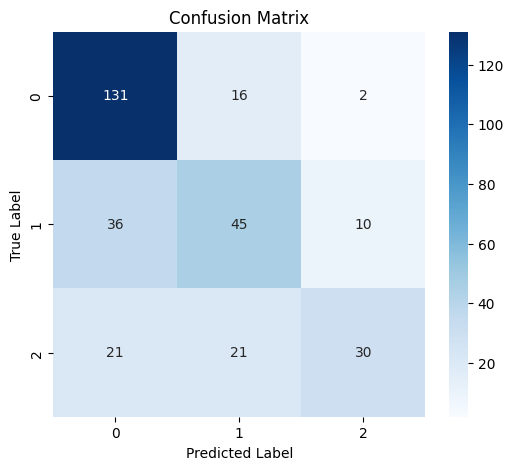

In [25]:
#SVM

model =" _0827"


# === 1. データの読み込み ===
merged_data_csv = f"/home/data/{data}/feature.csv"
df = pd.read_csv(merged_data_csv)
# === 2. 特徴量とターゲット変数の定義 ===
X = df[["MSE", "size_count", "R"]]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=100, random_state=56021, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=56021, stratify=y)
# 訓練データとテストデータのクラスごとのカウント
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# 結果を表示
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. 特徴量の標準化 ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 5. SVMの学習 (RBFカーネル) ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
svm_model.fit(X_train, y_train)


# 学習済みモデルを保存
model_path = f"svm_model{model}.pkl"
joblib.dump(svm_model, model_path)

# 標準化のスケーラーも保存
scaler_path = f"scaler{model}.pkl"
joblib.dump(scaler, scaler_path)


# === 6. 予測と評価 ===
y_pred = svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print(report_df.round(4))

# y_testが持つインデックスを使い、元のdfからテストデータに該当する行だけを抽出
test_data_with_results = df.loc[y_test.index].copy()

# 抽出したテストデータに、予測結果の列を追加
# これで左辺(test_data_with_results)と右辺(y_pred)の行数が一致する
test_data_with_results['Predicted_Label'] = y_pred

# 結果を新しいCSVファイルとして保存
output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [17]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# === 0. 事前準備と設定 ===
# 'data' 変数が未定義のため、ご自身の環境に合わせて設定してください
# 例: data = "0620_dicomo_dataset"
data = "0620_dicomo_dataset"  # ★ご自身のディレクトリ名に合わせて変更してください★
model_name_suffix = "_dicomo"

# ==================================================================
# ▼▼▼ 変更点 ▼▼▼
# ==================================================================
# ★★★ Seed値探索の設定 ★★★
start = 100000
N_SEEDS_TO_TRY = 200000  # 試行するseed値の数（0からN_SEEDS_TO_TRY-1まで）
TARGET_METRIC = 'accuracy' # 最適化の指標を 'accuracy' に変更
# ==================================================================

# === 1. データの読み込み ===
merged_data_csv = f"/home/data/{data}/feature.csv"
df = pd.read_csv(merged_data_csv)

# === 2. 特徴量とターゲット変数の定義 ===
X = df[["MSE", "size_count", "R"]]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. Seed値探索ループ ===
all_results = []
print(f"--- Starting Seed Search (0 to {N_SEEDS_TO_TRY-1}) ---")

for seed in range(start,N_SEEDS_TO_TRY+1):
    # --- 3a. 訓練データとテストデータに分割 ---
    # random_stateにループ変数seedを指定
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=100, random_state=seed, stratify=y
    )

    # --- 3b. 特徴量の標準化 ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- 3c. SVMの学習 ---
    svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
    svm_model.fit(X_train_scaled, y_train)

    # --- 3d. 予測と評価指標の記録 ---
    y_pred = svm_model.predict(X_test_scaled)
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    # 評価指標をリストに追加
    accuracy = report_dict['accuracy']
    # 'macro avg'のf1-scoreも記録しておく
    f1 = report_dict['macro avg']['f1-score']
    all_results.append({'seed': seed, 'accuracy': accuracy, 'f1_score': f1})
    
    print(f"Seed {seed:4d}: Accuracy = {accuracy:.4f}, Macro F1-Score = {f1:.4f}")

# === 4. 最適なSeedの特定と結果の集計 ===
results_df = pd.DataFrame(all_results)

# TARGET_METRICに基づいて最適なseedを見つける
if TARGET_METRIC == 'f1-score':
    print("\nOptimizing for: F1-Score")
    best_result = results_df.loc[results_df['f1_score'].idxmax()]
else:
    # こちらのロジックが実行される
    print("\nOptimizing for: Accuracy")
    best_result = results_df.loc[results_df['accuracy'].idxmax()]

best_seed = int(best_result['seed'])

print("\n--- Seed Search Finished ---")
print("All Seed Results:")
print(results_df)
print("\nPerformance Statistics:")
print(results_df[['accuracy', 'f1_score']].describe())
print("\n---------------------------------")
print(f"★★★ Best Seed Found (based on {TARGET_METRIC}): {best_seed} ★★★")
print(f"Best Seed's Accuracy: {best_result['accuracy']:.4f}")
print(f"Best Seed's Macro F1-Score: {best_result['f1_score']:.4f}")
print("---------------------------------")


# === 5. 最適なSeedで最終的なモデルを再学習・保存 ===
print(f"\n--- Training and Saving Final Model with Best Seed: {best_seed} ---")

# --- 5a. データ分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=100, random_state=best_seed, stratify=y
)

# --- 5b. 標準化 ---
final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)

# --- 5c. 学習 ---
final_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
final_model.fit(X_train_final, y_train)

# --- 5d. モデルとスケーラーの保存 ---
model_path = f"svm_model_best_seed_{best_seed}{model_name_suffix}.pkl"
joblib.dump(final_model, model_path)
print(f"Final model saved to {model_path}")

scaler_path = f"scaler_best_seed_{best_seed}{model_name_suffix}.pkl"
joblib.dump(final_scaler, scaler_path)
print(f"Final scaler saved to {scaler_path}")


# === 6. 最終モデルでの予測と評価 ===
y_pred_final = final_model.predict(X_test_final)

# --- 6a. Classification Report ---
final_report_df = pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True)).transpose()
print("\nFinal Model Classification Report (Best Seed):")
print(final_report_df.round(4))

# --- 6b. 予測結果をCSVに保存 ---
test_data_with_results = df.loc[y_test.index].copy()
test_data_with_results['Predicted_Label'] = y_pred_final
output_path = f"/home/data/{data}/predicted_results_best_seed_{best_seed}{model_name_suffix}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"Final prediction results saved to {output_path}")

# --- 6c. 混同行列の可視化 ---
cm = confusion_matrix(y_test, y_pred_final)
labels = sorted(y.unique())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Final Confusion Matrix (Seed: {best_seed})")
plt.show()

--- Starting Seed Search (0 to 199999) ---
Seed 100000: Accuracy = 0.6679, Macro F1-Score = 0.6635
Seed 100001: Accuracy = 0.6603, Macro F1-Score = 0.6594
Seed 100002: Accuracy = 0.6641, Macro F1-Score = 0.6621
Seed 100003: Accuracy = 0.6221, Macro F1-Score = 0.6234
Seed 100004: Accuracy = 0.6450, Macro F1-Score = 0.6502
Seed 100005: Accuracy = 0.6412, Macro F1-Score = 0.6452
Seed 100006: Accuracy = 0.6679, Macro F1-Score = 0.6694
Seed 100007: Accuracy = 0.6641, Macro F1-Score = 0.6649
Seed 100008: Accuracy = 0.6679, Macro F1-Score = 0.6655
Seed 100009: Accuracy = 0.6870, Macro F1-Score = 0.6883
Seed 100010: Accuracy = 0.6908, Macro F1-Score = 0.6848
Seed 100011: Accuracy = 0.6870, Macro F1-Score = 0.6841
Seed 100012: Accuracy = 0.6947, Macro F1-Score = 0.6973
Seed 100013: Accuracy = 0.6832, Macro F1-Score = 0.6868
Seed 100014: Accuracy = 0.6947, Macro F1-Score = 0.6922
Seed 100015: Accuracy = 0.6641, Macro F1-Score = 0.6640
Seed 100016: Accuracy = 0.6641, Macro F1-Score = 0.6632
Seed 

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # StandardScalerは読み込んだscalerで使うため残します
from sklearn.svm import SVC # SVCはjoblibがモデルを正しく解釈するためにインポートしておくのが安全です
from sklearn.metrics import classification_report, confusion_matrix

# === 0. 事前準備 ===
# 評価したいデータセットと、読み込むモデルの指定
data = "0620_dicomo_dataset"  # ★評価したいデータが含まれるディレクトリ名に合わせて変更してください★
model_name_suffix = "_dicomo" # ★読み込むモデルの接尾辞を指定してください★


# === 1. データの読み込み ===
# 評価したいデータを含むCSVファイルを指定
merged_data_csv = f"/home/data/{data}/feature.csv"
df = pd.read_csv(merged_data_csv)

# === 2. 特徴量とターゲット変数の定義 ===
X = df[["MSE", "size_count", "R"]]  # 特徴量
y = df["Label"]  # 目的変数


# ==================================================================
# ▼▼▼ ここからコードを大きく変更 ▼▼▼
# ==================================================================

# === 3. 評価用データの準備 ===
# ※訓練は行わないが、評価のために元データからテストセットを分割します。
# 以前の学習時と同じ random_state を使うと、同じテストデータで評価できます。
# 訓練データ (X_train, y_train) は不要なため、`_`で受け取って破棄します。
_, X_test, _, y_test = train_test_split(X, y, train_size=100, random_state=56021, stratify=y)

# 評価に使うデータの情報を表示
print("Test Data for Evaluation Distribution:")
print(y_test.value_counts().sort_index())


# === 4. 学習済みモデルとスケーラーの読み込み ===
model_path = f"svm_model{model_name_suffix}.pkl"
scaler_path = f"scaler{model_name_suffix}.pkl"

try:
    print(f"\nLoading model from: {model_path}")
    svm_model = joblib.load(model_path)
    
    print(f"Loading scaler from: {scaler_path}")
    scaler = joblib.load(scaler_path)
except FileNotFoundError as e:
    print(f"\nError: {e}")
    print("必要なモデルファイルまたはスケーラーファイルが見つかりません。")
    print("先にモデルを学習・保存するスクリプトを実行してください。")
    exit() # プログラムを終了


# === 5. テストデータの特徴量を標準化 ===
# 読み込んだscalerを使い、テストデータのみを変換します (fitは行いません)
X_test = scaler.transform(X_test)

# === 学習ステップはここにはありません ===

# ==================================================================
# ▲▲▲ コードの変更はここまで ▲▲▲
# ==================================================================


# === 6. 予測と評価 ===
print("\nPredicting with the loaded model...")
y_pred = svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print("\nClassification Report:")
print(report_df.round(4))

# y_testが持つインデックスを使い、元のdfからテストデータに該当する行だけを抽出
test_data_with_results = df.loc[y_test.index].copy()

# 抽出したテストデータに、予測結果の列を追加
test_data_with_results['Predicted_Label'] = y_pred

# 結果を新しいCSVファイルとして保存
# ファイル名が重複しないように "EVAL_predicted_results" のように変更
output_path = f"/home/data/{data}/EVAL_predicted_results{model_name_suffix}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"\nPrediction results saved to {output_path}")


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y.unique())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Pre-trained Model")
plt.show()

In [ ]:
# #予測
# # === モデルとスケーラーの読み込み ===
# model_path = f"svm_model{model}.pkl"
# scaler_path = f"scaler{model}.pkl"

# svm_model = joblib.load(model_path)
# scaler = joblib.load(scaler_path)

# # === 新しいデータの読み込み ===
# # df = pd.DataFrame(merged)
# df = pd.read_csv(f'/home/data/{data}/feature.csv')
# df = pd.DataFrame(df)

# # === 特徴量の抽出と標準化 ===
# X_new = df[["MSE", "size_count", "R"]]  # 学習時と同じ特徴量を使用
# X_new = scaler.transform(X_new)  # 標準化

# # === 予測 ===
# y_pred_new = svm_model.predict(X_new)

# # 結果をDataFrameに追加
# df["Predicted_Label"] = y_pred_new

# # 予測結果の確認
# print([["MSE", "size_count", "R", "Predicted_Label"]])

# # CSVとして保存（オプション）
# df.to_csv(f"/home/data/{data}/predicted_results.csv", index=False)

# # 精度の表示
# accuracy = accuracy_score(df["Label"], df["Predicted_Label"])
# precision = precision_score(df["Label"], df["Predicted_Label"], average='macro')
# recall = recall_score(df["Label"], df["Predicted_Label"], average='macro')
# f1 = f1_score(df["Label"], df["Predicted_Label"], average='macro')
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1: {f1:.4f}")
# # 混同行列の可視化
# cm = confusion_matrix(df["Label"], df["Predicted_Label"])
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()

In [ ]:
# df  = pd.read_csv("/home/data/jikuari_maesyori_gakusyu/predicted_results.csv")
# df = pd.DataFrame(df)
# # 正解ラベルと予測ラベル
# y_true = df["Label"]
# y_pred = df["Predicted_Label"]

# # 精度 (accuracy)
# accuracy = accuracy_score(y_true, y_pred)
# print("Accuracy:", accuracy)

# # 詳細レポート
# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, digits=4))


In [ ]:
# import hida
# a = hida.Hida_file_jikuari(
#                             img_path = "/home/data/jikuari_maesyori_gakusyu/combined/B/combined_1_18.jpg",
#                            mask_path = "/home/data/jikuari_maesyori_gakusyu/mask/B/mask_1_18.jpg", 
#                            method="45rotate")
# result = a.main()
# print(result)

In [ ]:
# import hida
# a = hida.Hida_folder(base_dir="/home/data/maesyori_img")
# result = a.run_all()
# print(result)

In [ ]:
# import size

# a = size.Size_file("/home/data/maesyori_img/mask/collage_1/mask_1_1.jpg")
# result = a.count_white_pixels()
# print(result)

In [ ]:
# import size_module
# import os
# import cv2
# import numpy as np
# b = size_module.Size_folder(base_dir="/home/data/maesyori_img")
# result = b.count_white_pixels()
# print(result)

In [ ]:
# import keijo
# analyzer = keijo.Keijo_file("/home/data/maesyori_img/mask/collage_1/mask_1_1.jpg")
# result = analyzer.run()
# print(result)

In [ ]:
# import keijo
# analyzer = keijo.Keijo_folder(base_dir="/home/data/maesyori_img")
# result = analyzer.run()
# print(result)